# 01 · Variational Quantum Circuit phân loại hoa Iris

**Mục tiêu:** xây một mạch lượng tử có tham số (VQC) 4 qubit bằng PennyLane, huấn luyện nó giống như huấn luyện một mạng neural, và phân loại hai loài hoa Iris.

**Điểm chính của notebook:** cùng một mạch, chỉ đổi cổng mã hóa dữ liệu từ `RX` sang `RY`, độ chính xác tăng từ mức đoán bừa lên 100%. Phần 5 giải thích vì sao.

## 1. Thư viện

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

## 2. Chuẩn bị dữ liệu

- Chọn hai loài hoa, dùng đủ 4 đặc trưng (mỗi đặc trưng đưa vào 1 qubit).
- Chia **70% train / 30% test** để đánh giá trên dữ liệu mạch chưa từng thấy.
- Chuẩn hóa bằng trung bình và độ lệch chuẩn **của tập train** (tránh rò rỉ thông tin từ tập test).
- Đổi nhãn sang `-1 / +1` cho khớp với output của mạch, vốn nằm trong khoảng `[-1, 1]`.

In [2]:
iris = load_iris()

def make_data(class_a, class_b, seed=42):
    mask = np.isin(iris.target, [class_a, class_b])
    X = iris.data[mask]
    y = np.where(iris.target[mask] == class_a, -1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)

    mean, std = X_train.mean(axis=0), X_train.std(axis=0)
    return (X_train - mean) / std, (X_test - mean) / std, y_train, y_test

# 0 = Setosa, 1 = Versicolor, 2 = Virginica
X_train, X_test, y_train, y_test = make_data(0, 1)
print(f"Train: {len(X_train)} mẫu, Test: {len(X_test)} mẫu, mỗi mẫu {X_train.shape[1]} đặc trưng")

Train: 70 mẫu, Test: 30 mẫu, mỗi mẫu 4 đặc trưng


## 3. Mạch lượng tử

Cấu trúc mạch (4 qubit, 12 trọng số):

1. **Mã hóa dữ liệu:** mỗi đặc trưng thành một góc quay (`RX` hoặc `RY`, chọn qua tham số `encoding`).
2. **Lớp 1:** 4 cổng `RY` có trọng số, rồi `CNOT` nối cặp (0,1) và (2,3).
3. **Lớp 2:** 4 cổng `RY` có trọng số, rồi `CNOT(1,2)` nối hai cặp lại với nhau để thông tin của cả 4 đặc trưng trộn vào nhau.
4. **Lớp 3:** 4 cổng `RY` có trọng số.
5. **Đo:** trung bình giá trị `PauliZ` của 4 qubit, ra một số trong `[-1, 1]`. Dương thì đoán nhãn `+1`, âm thì đoán `-1`.

Các lớp `RY` được ngăn cách bởi `CNOT`, vì hai cổng `RY` liền nhau trên cùng một qubit sẽ gộp thành một (`RY(a)·RY(b) = RY(a+b)`) và không làm mạch mạnh hơn.

In [3]:
dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev)
def circuit(x, weights, encoding="RY"):
    encode = qml.RY if encoding == "RY" else qml.RX

    # mã hóa dữ liệu
    for i in range(4):
        encode(x[i], wires=i)

    # lớp 1
    for i in range(4):
        qml.RY(weights[i], wires=i)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[2, 3])

    # lớp 2
    for i in range(4):
        qml.RY(weights[4 + i], wires=i)
    qml.CNOT(wires=[1, 2])

    # lớp 3
    for i in range(4):
        qml.RY(weights[8 + i], wires=i)

    return qml.expval((qml.PauliZ(0) + qml.PauliZ(1) + qml.PauliZ(2) + qml.PauliZ(3)) / 4)

print(qml.draw(circuit)(X_train[0], np.zeros(12)))

0: ──RY(1.94)──RY(0.00)─╭●──RY(0.00)──RY(0.00)───────────┤ ╭<0.25*𝓗>
1: ──RY(0.04)──RY(0.00)─╰X──RY(0.00)─╭●─────────RY(0.00)─┤ ├<0.25*𝓗>
2: ──RY(1.30)──RY(0.00)─╭●──RY(0.00)─╰X─────────RY(0.00)─┤ ├<0.25*𝓗>
3: ──RY(1.31)──RY(0.00)─╰X──RY(0.00)──RY(0.00)───────────┤ ╰<0.25*𝓗>


## 4. Huấn luyện

- **Loss:** MSE giữa output của mạch và nhãn `-1/+1`.
- **Khởi tạo trọng số nhỏ** trong khoảng `[0, 0.1]` để tránh barren plateau (gradient gần bằng 0 khiến mạch không học được).
- **Optimizer:** Adam, learning rate 0.1. Gradient được PennyLane tính tự động, tương tự backpropagation trong PyTorch.

In [4]:
def predict(X, weights, encoding):
    outputs = np.array([circuit(xi, weights, encoding=encoding) for xi in X])
    return np.where(outputs > 0, 1, -1)

def accuracy(X, y, weights, encoding):
    return np.mean(predict(X, weights, encoding) == y)

def train(X, y, encoding, steps=200, seed=42):
    np.random.seed(seed)
    weights = np.random.uniform(0, 0.1, 12, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=0.1)

    def cost(w):
        outputs = np.array([circuit(xi, w, encoding=encoding) for xi in X])
        return np.mean((outputs - y) ** 2)

    history = []
    for step in range(steps):
        weights, loss = opt.step_and_cost(cost, weights)
        history.append(float(loss))
        if step % 40 == 0:
            print(f"[{encoding}] step {step:3d}: loss {loss:.4f}")
    return weights, history

In [5]:
results = {}
for enc in ["RX", "RY"]:
    w, hist = train(X_train, y_train, encoding=enc)
    results[enc] = (w, hist)
    print(f"--> {enc}: train acc = {accuracy(X_train, y_train, w, enc):.1%}, "
          f"test acc = {accuracy(X_test, y_test, w, enc):.1%}\n")

[RX] step   0: loss 1.1783
[RX] step  40: loss 0.9671
[RX] step  80: loss 0.9642
[RX] step 120: loss 0.9630
[RX] step 160: loss 0.9630
--> RX: train acc = 51.4%, test acc = 43.3%

[RY] step   0: loss 1.2712
[RY] step  40: loss 0.0730
[RY] step  80: loss 0.0599
[RY] step 120: loss 0.0574
[RY] step 160: loss 0.0573
--> RY: train acc = 100.0%, test acc = 100.0%



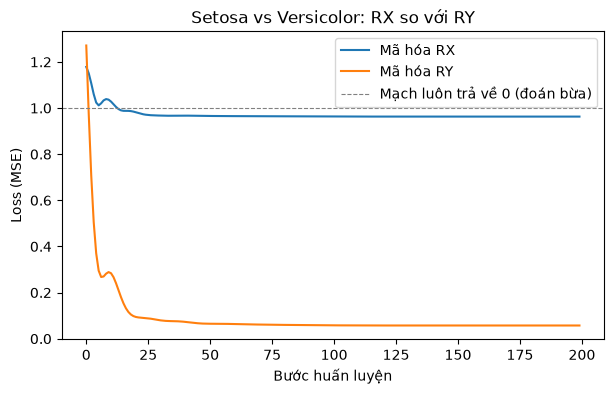

In [6]:
plt.figure(figsize=(7, 4))
for enc, (w, hist) in results.items():
    plt.plot(hist, label=f"Mã hóa {enc}")
plt.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Mạch luôn trả về 0 (đoán bừa)")
plt.xlabel("Bước huấn luyện")
plt.ylabel("Loss (MSE)")
plt.title("Setosa vs Versicolor: RX so với RY")
plt.legend()
plt.show()

## 5. Vì sao mã hóa RX không học được?

**Quan sát:** với `RX`, loss gần như đứng yên quanh 1.0 và accuracy chỉ quanh 50%, dù Setosa và Versicolor là cặp rất dễ tách.

**Giải thích bằng quả cầu Bloch:** mỗi qubit là một cây kim, ban đầu chỉ lên cực Bắc (|0⟩). Phép đo `PauliZ` chỉ cho biết **độ cao** của đầu kim, không biết kim nghiêng về hướng nào.

- Sau khi chuẩn hóa, Setosa có giá trị âm (khoảng −1), Versicolor có giá trị dương (khoảng +1).
- `RX(x)` làm kim nghiêng **sang trái hoặc phải** một góc x. Độ cao đầu kim là `cos(x)`, mà `cos(−x) = cos(x)`, nên hai loài cho cùng độ cao.
- Các trọng số `RY(w)` quay quanh một trục **khác**. Chúng tác động lên hai cây kim theo cách đối xứng nhau, nên không phá được sự đối xứng này. Toàn mạch (`RX`, `RY`, `CNOT`) có tính chất: đổi dấu toàn bộ x chỉ cho ra trạng thái liên hợp phức, và xác suất đo giữ nguyên. Vậy mạch **không thể phân biệt x với −x**, train bao lâu cũng vậy.

**Khi mã hóa bằng `RY`:** dữ liệu và trọng số quay **quanh cùng một trục**, nên cộng lại thành `x + w`. Một qubit cho `cos(x + w)`, và trọng số `w` có thể dịch hàm cos để x âm và x dương cho ra độ cao khác nhau.

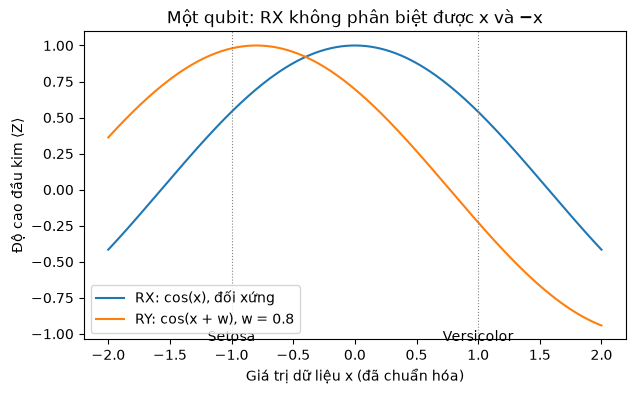

In [7]:
xs = np.linspace(-2, 2, 200)
w = 0.8
plt.figure(figsize=(7, 4))
plt.plot(xs, np.cos(xs), label="RX: cos(x), đối xứng")
plt.plot(xs, np.cos(xs + w), label=f"RY: cos(x + w), w = {w}")
for x0, name in [(-1, "Setosa"), (1, "Versicolor")]:
    plt.axvline(x0, color="gray", linestyle=":", linewidth=0.8)
    plt.text(x0, -1.05, name, ha="center")
plt.xlabel("Giá trị dữ liệu x (đã chuẩn hóa)")
plt.ylabel("Độ cao đầu kim ⟨Z⟩")
plt.title("Một qubit: RX không phân biệt được x và −x")
plt.legend()
plt.show()

## 6. Thử thách khó hơn: Versicolor vs Virginica

Hai loài này chồng lấn nhau nhiều hơn, nên đây là phép thử thật sự cho mạch.

In [8]:
X_train2, X_test2, y_train2, y_test2 = make_data(1, 2)
w2, hist2 = train(X_train2, y_train2, encoding="RY")
print(f"Versicolor vs Virginica (RY): train acc = {accuracy(X_train2, y_train2, w2, 'RY'):.1%}, "
      f"test acc = {accuracy(X_test2, y_test2, w2, 'RY'):.1%}")

[RY] step   0: loss 1.4347
[RY] step  40: loss 0.3186
[RY] step  80: loss 0.2905
[RY] step 120: loss 0.2902
[RY] step 160: loss 0.2902
Versicolor vs Virginica (RY): train acc = 95.7%, test acc = 90.0%


## 7. Kết luận

- Cấu trúc mạch quyết định mạch **có thể** học được gì: mã hóa `RX` kết hợp trọng số `RY` làm mạch "mù dấu", không train nào sửa được.
- Đổi sang mã hóa `RY` (cùng trục với trọng số) giúp mạch đạt 100% trên tập test với Setosa/Versicolor, và kết quả tốt trên cặp khó Versicolor/Virginica.
- Kết quả trên đều chạy bằng simulator (`default.qubit`), chưa chạy trên phần cứng lượng tử thật.